# Chapter 1: Data Exploration

In this chapter we load the RadioML 2016.10a dataset, explore its structure, and store it in a SQLite database for querying.

## What we cover
- Loading the RadioML pickle file
- Understanding IQ samples
- Exploring modulation types and SNR levels
- Visualizing signal distributions
- Storing data in SQLite with SQLAlchemy

This is visualized in the following figure

![Chapter structure](../figures/ch01_data_exploration/00_summary.jpeg)


# Chapter Contents

| Step | Description | Link |
|---|---|---|
| **Step 1** | [Load Pickle File](#sec-loading) |
| **Step 2** | [Explore Dataset Structure](#sec-structure) |
| **Step 3** | [Inspect NumPy Arrays] | [Go to Step 3](#sec-numpy) |
| **Step 4** | [Plot I and Q Channels] | [Go to Step 4](#sec-visualizing) |
| **Step 5** | [Compare High vs Low SNR] | [Go to Step 5](#sec-snr) |
| **Step 6** | [All 11 Modulation Types] | [Go to Step 6](#sec-modulations) |
| **Step 7** | [Sample Distribution] | [Go to Step 7](#sec-distribution) |
| **Step 8** | [Convert to Pandas DataFrame] | [Go to Step 8](#sec-dataframe) |
| **Step 9** | [Explore DataFrame] | [Go to Step 9](#sec-exploration) |
| **Step 10** | [Store in SQLite] | [Go to Step 10](#sec-sqlite) |
| **Step 11** | [SQL Queries] | [Go to Step 11](#sec-sql) |
| **Step 12** | [Chapter Summary] | [Go to Summary](#sec-summary) |

In [1]:
# ─────────────────────────────────────────
# Imports
# ─────────────────────────────────────────

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import yaml

# Add src/ to path so we can import our modules
sys.path.append("../../")
from src.data_loader import load_config, load_raw_data, parse_to_dataframe, get_dataset_summary

# Plot styling
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)

print("✅ Imports successful!")

✅ Imports successful!


![data_loader methods](../figures/ch01_data_exploration/01_methods.jpeg)

In [2]:
# ─────────────────────────────────────────
# Load config
# ─────────────────────────────────────────
config = load_config("../../config.yaml")

print(f"Project: {config['project']['name']}")
print(f"Version: {config['project']['version']}")
print(f"Raw data path: {config['paths']['raw_data']}")
print(f"Database path: {config['paths']['database']}")

2026-05-19 13:38:13,275 — INFO — Config loaded successfully


Project: RF Signal Classifier
Version: 0.1.0
Raw data path: data/raw/RML2016.10a_dict.pkl
Database path: data/rf_signals.db


## 1. Loading the Raw Dataset {#sec-loading}

We use our `data_loader.py` module to load the RadioML 2016.10a pickle file.
The dataset is a Python dictionary where each key is a tuple of 
`(modulation_type, snr_level)` and each value is a NumPy array of IQ samples
with shape `(1000, 2, 128)` — 1000 samples, 2 channels (I and Q), 128 time steps.

In [3]:
from pathlib import Path

# Get absolute path to project root
PROJECT_ROOT = Path("../../").resolve()
data_path = PROJECT_ROOT / config['paths']['raw_data']

print(f"Looking for dataset at: {data_path}")

raw_data = load_raw_data(str(data_path))

print(f"Type: {type(raw_data)}")
print(f"Number of keys: {len(raw_data)}")
print(f"Sample keys: {list(raw_data.keys())[:5]}")

2026-05-19 13:38:13,314 — INFO — Loading dataset from /Users/carlosreyes/Desktop/AI/projects/signal/data/raw/RML2016.10a_dict.pkl


Looking for dataset at: /Users/carlosreyes/Desktop/AI/projects/signal/data/raw/RML2016.10a_dict.pkl


2026-05-19 13:38:14,939 — INFO — Dataset loaded — 220 modulation/SNR combinations


Type: <class 'dict'>
Number of keys: 220
Sample keys: [('QPSK', 2), ('PAM4', 8), ('AM-DSB', -4), ('GFSK', 6), ('QAM64', 8)]


In [4]:
# ─────────────────────────────────────────
# Explore dataset structure
# ─────────────────────────────────────────

# Get all keys
keys = list(raw_data.keys())

# Extract unique modulations and SNR levels
modulations = sorted(list(set([k[0] for k in keys])))
snr_levels = sorted(list(set([k[1] for k in keys])))

# Get shape of one sample
sample_shape = raw_data[keys[0]].shape

print(f"Total keys (mod, snr) combinations: {len(keys)}")
print(f"\nModulation types ({len(modulations)}):")
for m in modulations:
    print(f"  - {m}")
print(f"\nSNR levels ({len(snr_levels)}):")
print(f"  {snr_levels}")
print(f"\nShape of one entry: {sample_shape}")
print(f"  → {sample_shape[0]} samples")
print(f"  → {sample_shape[1]} channels (I and Q)")
print(f"  → {sample_shape[2]} time steps")

Total keys (mod, snr) combinations: 220

Modulation types (11):
  - 8PSK
  - AM-DSB
  - AM-SSB
  - BPSK
  - CPFSK
  - GFSK
  - PAM4
  - QAM16
  - QAM64
  - QPSK
  - WBFM

SNR levels (20):
  [-20, -18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18]

Shape of one entry: (1000, 2, 128)
  → 1000 samples
  → 2 channels (I and Q)
  → 128 time steps


## 2. Dataset Structure {#sec-structure}

![Dataset structure](../figures/ch01_data_exploration/02_dataset.jpeg)

### Understanding the RadioML 2016.10a Dataset

The RadioML 2016.10a dataset is a synthetic radio signal dataset generated using GNU Radio and released by DeepSig. It is the standard benchmark dataset for RF signal classification research.

### The Data Cube
The dataset can be thought of as a **3D cube** with three dimensions:

| Dimension | Description | Values |
|---|---|---|
| **X axis** | Modulation type | 11 types (8PSK, AM-DSB, AM-SSB, BPSK, CPFSK, GFSK, PAM4, QAM16, QAM64, QPSK, WBFM) |
| **Y axis** | SNR level | 20 levels from -20dB to +18dB in steps of 2dB |
| **Z axis** | Samples per combination | 1000 samples |

This gives us **11 × 20 × 1000 = 220,000 total signals**.

### Each Signal
Every single signal in the dataset is stored as a NumPy array of shape `(2, 128)`:
- **Row 0** → I channel (In-phase) — 128 time steps
- **Row 1** → Q channel (Quadrature) — 128 time steps

Together I and Q fully describe the amplitude and phase of the RF signal at each point in time.

### Signal-to-Noise Ratio (SNR)
SNR measures how much signal there is relative to background noise:
- **High SNR (+18dB)** → Clean signal, easy to classify
- **Low SNR (-20dB)** → Very noisy signal, hard to classify
- A key goal of this project is to evaluate how well our classifier performs **across all SNR levels**

### Why IQ Samples?
IQ (In-phase and Quadrature) representation is the standard way to digitally represent RF signals. Every software defined radio (SDR) 
system outputs IQ data. By working with IQ samples directly we are working with the same format used in real-world wireless systems.

## 3. NumPy Array Structure {#sec-numpy}

![NumPy Array Structure](../figures/ch01_data_exploration/03_numpy_array_structure.jpeg)


Each entry in the RadioML dictionary is a NumPy `float32` array with shape `(1000, 2, 128)`:

| Axis | Size | Description |
|---|---|---|
| **Axis 0** | 1000 | One complete RF signal per index |
| **Axis 1** | 2 | Row 0 = I channel, Row 1 = Q channel |
| **Axis 2** | 128 | 128 sampled time steps per channel |

### Why Axis 1 has exactly 2 rows — I and Q Explained
IQ representation is the standard way software defined radios (SDRs) capture RF signals digitally. Think of a signal as a point rotating 
around a circle over time:

- **I (In-phase)** → the horizontal (X) component of that rotation
- **Q (Quadrature)** → the vertical (Y) component of that rotation

Together I and Q fully describe both the **amplitude** and **phase** of the signal at every moment in time. This is why there are always 
exactly 2 rows — one for each component.

### Value Range
The raw IQ values are very small `float32` numbers centered around zero:
- **Min:** -0.0631
- **Max:** 0.1642
- **Mean:** ~0.0000
- **Std:** 0.0060

This near-zero mean is expected — RF signals oscillate symmetrically around zero by nature.

## 4. Visualizing a Single Signal {#sec-visualizing}

Let's plot the I and Q channels of a single BPSK signal at high SNR (+18dB) to see what a clean RF signal looks like in the time domain.

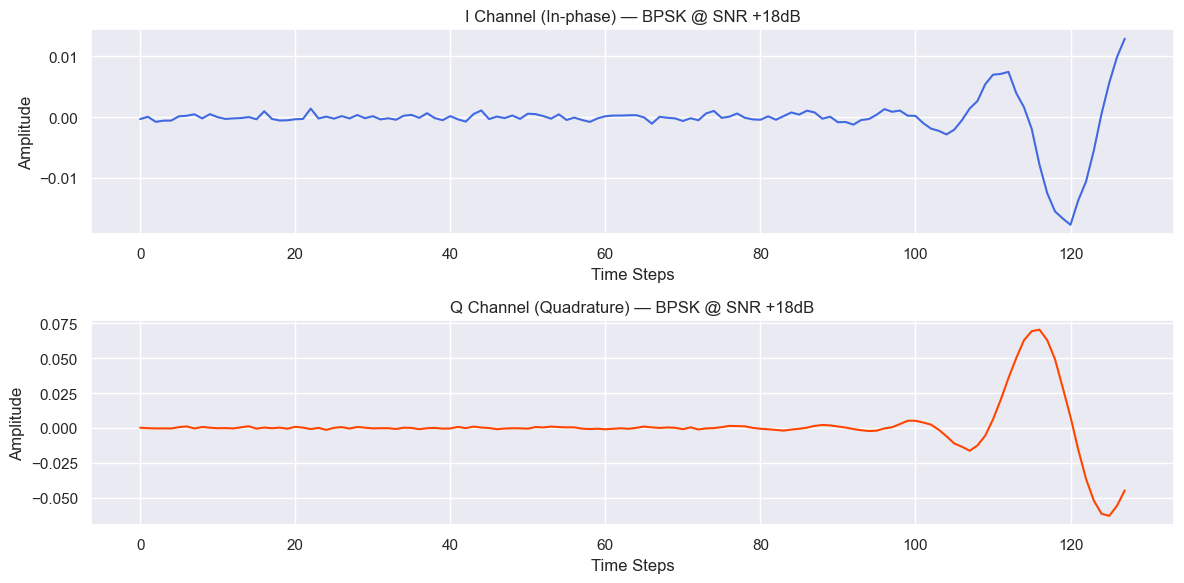

In [5]:
# ─────────────────────────────────────────
# Plot I and Q channels of a single signal
# ─────

# Get one BPSK signal at high SNR
signal = raw_data[("BPSK", 18)][0] # 1st signal

i_channel = signal[0] # 128 time steps
q_channel = signal[1] # 128 time steps
time_steps = np.arange(128)

# Plot
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12,6))

ax1.plot(time_steps, i_channel, color="royalblue", linewidth=1.5)
ax1.set_title("I Channel (In-phase) — BPSK @ SNR +18dB")
ax1.set_xlabel("Time Steps")
ax1.set_ylabel("Amplitude")
ax1.grid(True)

ax2.plot(time_steps, q_channel, color="orangered", linewidth=1.5)
ax2.set_title("Q Channel (Quadrature) — BPSK @ SNR +18dB")
ax2.set_xlabel("Time Steps")
ax2.set_ylabel("Amplitude")
ax2.grid(True)

plt.tight_layout()
plt.show()


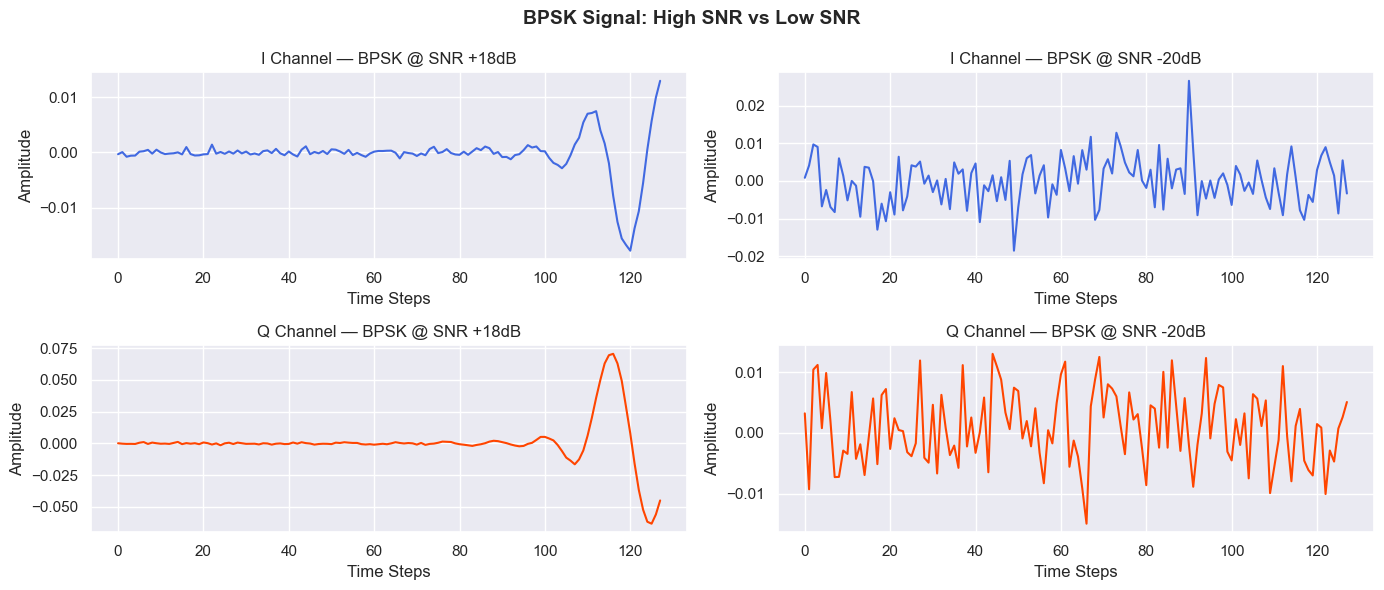

In [6]:
# ─────────────────────────────────────────
# Compare high vs low SNR
# ─────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 6))

for col, snr in enumerate([18, -20]):
    signal = raw_data[("BPSK", snr)][0]
    
    axes[0, col].plot(signal[0], color="royalblue", linewidth=1.5)
    axes[0, col].set_title(f"I Channel — BPSK @ SNR {snr:+}dB")
    axes[0, col].set_xlabel("Time Steps")
    axes[0, col].set_ylabel("Amplitude")
    axes[0, col].grid(True)

    axes[1, col].plot(signal[1], color="orangered", linewidth=1.5)
    axes[1, col].set_title(f"Q Channel — BPSK @ SNR {snr:+}dB")
    axes[1, col].set_xlabel("Time Steps")
    axes[1, col].set_ylabel("Amplitude")
    axes[1, col].grid(True)

plt.suptitle("BPSK Signal: High SNR vs Low SNR", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Effect of SNR on Signal Quality {#sec-snr}


The plots above compare the same BPSK modulation at two extreme SNR levels:

| SNR Level | Signal Quality | Classification Difficulty |
|---|---|---|
| **+18dB** | Clean, clear phase transitions visible | Easy |
| **-20dB** | Completely buried in noise, looks random | Very Hard |

This is why evaluating our classifier **across all SNR levels** is critical.
A good model should classify correctly at high SNR and gracefully degrade 
at low SNR — not fail completely.

## 6. All Modulation Types — I Channel Comparison {#sec-modulations}

Let's visualize the I channel of one signal from each modulation type at high SNR (+18dB) to see how they differ visually.

['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']


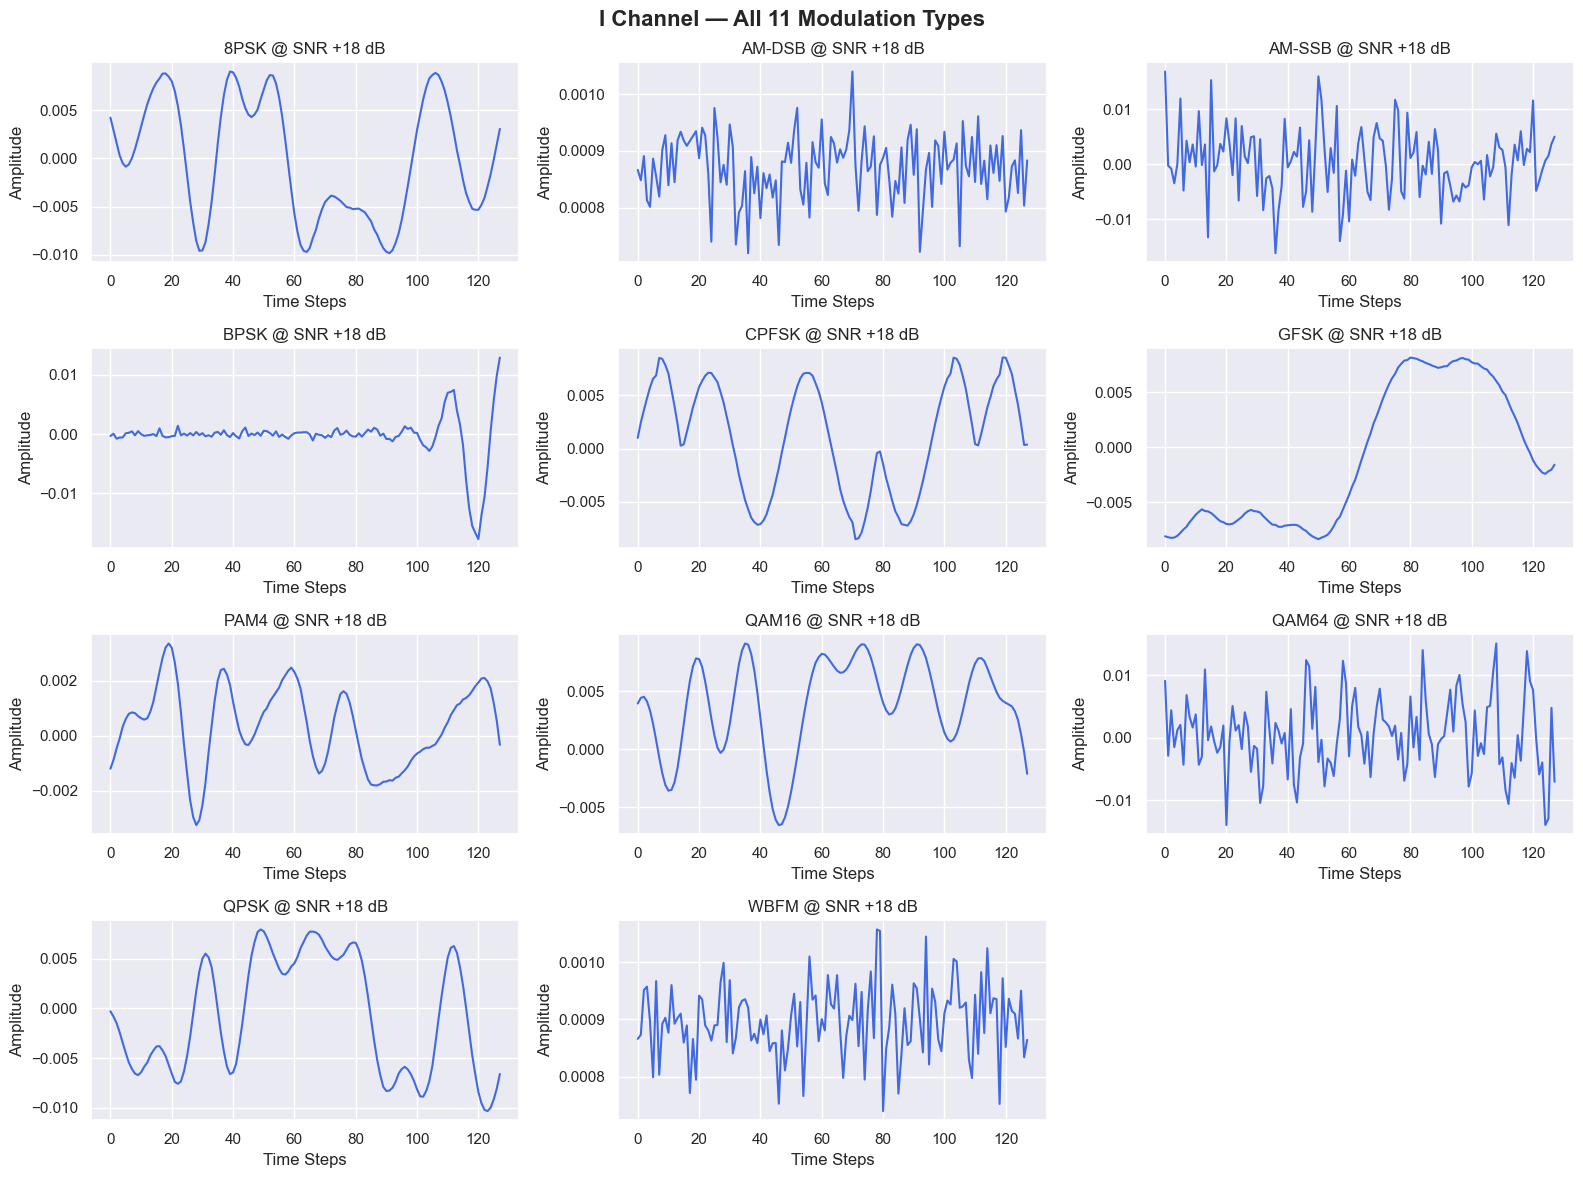

In [ ]:
# ─────────────────────────────────────────
# Plot all 11 modulation types
# ─────────────────────────────────────────

# Get list of modulations from raw_data keys
modulations = sorted(list(set([k[0] for k in raw_data.keys()])))
print(modulations)

# Create a 4x3 grid of subplots
fig, axes = plt.subplots(4,3, figsize=(16,12))
axes = axes.flatten()

for i, mod in enumerate(modulations):
    # Get the 1st signal of each modulation at SNR +18db
    signal = raw_data[(mod, 18)][0]

    # Plot I channel
    axes[i].plot(signal[0], color='royalblue',linewidth=1.5)
    axes[i].set_title(f"{mod} @ SNR +18 dB")
    axes[i].set_xlabel("Time Steps")
    axes[i].set_ylabel("Amplitude")
    axes[i].grid(True)

# Hide the last empty subplot
axes[-1].set_visible(False)

plt.suptitle("I Channel — All 11 Modulation Types", 
             fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Sample Distribution per Modulation Type {#sec-distribution}

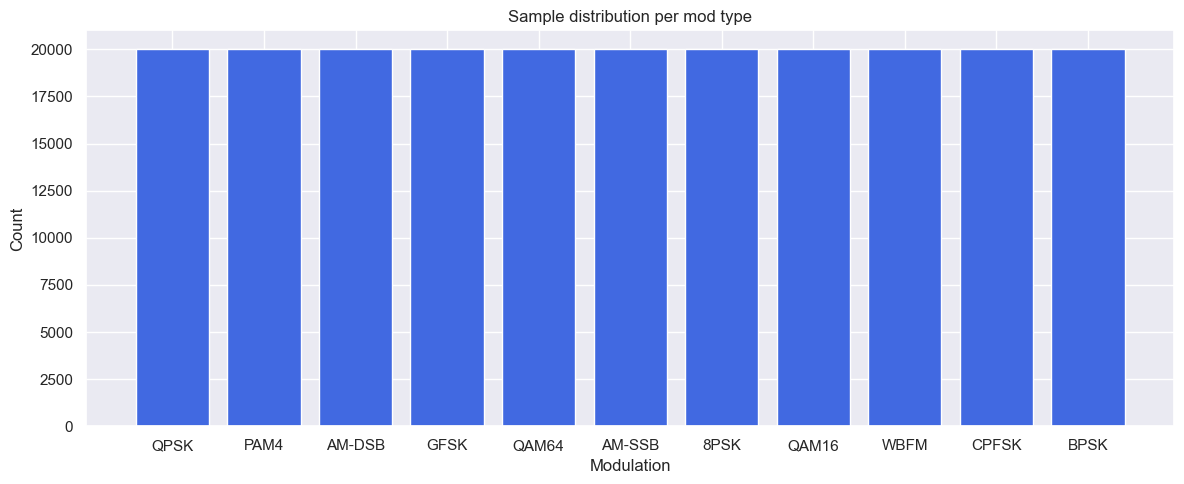

In [ ]:
# ─────────────────────────────────────────
# Sample distribution per modulation
# ─────────────────────────────────────────

# Count total samples per modulation
counts = {}
for(mod, snr), samples in raw_data.items():
    counts[mod] = counts.get(mod,0) + len(samples)

# Convert to df
df_counts = pd.DataFrame(list(counts.items()),
                         columns=["modulation","count"])
df_counts = df_counts.sort_values("count", ascending=True)

# Plot 
fig, ax = plt.subplots(figsize=(12,5))
ax.bar(df_counts["modulation"], df_counts["count"], color="royalblue")
ax.set_title("Sample distribution per mod type")
ax.set_xlabel("Modulation")
ax.set_ylabel("Count")
ax.grid(True, axis="y")
plt.tight_layout()
plt.show()


The dataset is perfectly balanced — exactly 20,000 samples per modulation type (1000 samples × 20 SNR levels).

## 8. Converting to Pandas DataFrame {#sec-dataframe}
For easier data handling the python dictionary is parsed into a dataframe
![Df Parsing](../figures/ch01_data_exploration/04_df_parsing.jpeg)

In [9]:
## 8. Converting to Pandas DataFrame

df = parse_to_dataframe(raw_data)

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nModulation types: {df['modulation'].nunique()}")
print(f"SNR levels: {sorted(df['snr'].unique())}")
print(f"\nFirst 5 rows:")
df.head()

2026-05-20 11:41:35,302 — INFO — Parsing dataset into DataFrame...
2026-05-20 11:41:39,562 — INFO — DataFrame created — 220,000 rows, 11 modulation types


Shape: (220000, 4)

Columns: ['modulation', 'snr', 'i_samples', 'q_samples']

Modulation types: 11
SNR levels: [np.int64(-20), np.int64(-18), np.int64(-16), np.int64(-14), np.int64(-12), np.int64(-10), np.int64(-8), np.int64(-6), np.int64(-4), np.int64(-2), np.int64(0), np.int64(2), np.int64(4), np.int64(6), np.int64(8), np.int64(10), np.int64(12), np.int64(14), np.int64(16), np.int64(18)]

First 5 rows:


,modulation,snr,i_samples,q_samples
0,QPSK,2,"[-0.005901471246033907, -0.0023458178620785475...","[-0.007795543409883976, -0.0078163743019104, -..."
1,QPSK,2,"[0.005032615270465612, 0.0009437998523935676, ...","[-0.00399943208321929, 0.001617817091755569, 0..."
2,QPSK,2,"[0.005239071324467659, 0.0073890695348382, 0.0...","[0.004199555143713951, 0.0073807029984891415, ..."
3,QPSK,2,"[-0.001985993469133973, -0.007150138262659311,...","[0.003058973466977477, 0.0052117155864834785, ..."
4,QPSK,2,"[0.006674405187368393, 0.0028359745629131794, ...","[-0.011892675422132015, -0.004061529878526926,..."


## 9. DataFrame Exploration {#sec-exploration}

Now that we have our data in a Pandas DataFrame we can explore it using built-in methods to understand the structure, data types, and distribution of our 220,000 signals.

In [11]:
print("=== Shape ===")
print(df.shape)

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Sample counts per modulation ===")
print(df.groupby('modulation')["snr"].count())

=== Shape ===
(220000, 4)

=== Data Types ===
modulation       str
snr            int64
i_samples     object
q_samples     object
dtype: object

=== Sample counts per modulation ===
modulation
8PSK      20000
AM-DSB    20000
AM-SSB    20000
BPSK      20000
CPFSK     20000
GFSK      20000
PAM4      20000
QAM16     20000
QAM64     20000
QPSK      20000
WBFM      20000
Name: snr, dtype: int64


## 10. Storing Data in SQLite {#sec-sqlite}

Now we store our DataFrame into a SQLite database using SQLAlchemy. This allows us to query the data using SQL — a critical skill for any data scientist.

### What we store
We store a **metadata table** with only `modulation`, `snr` and `signal_id` columns. Storing 220,000 raw IQ arrays in SQL would be inefficient — those stay in memory as a Pandas DataFrame.

### SQLAlchemy
SQLAlchemy is a Python library that lets you interact with SQL databases using Python code instead of raw SQL strings. It acts as a bridge between Pandas and SQLite.

```python
# The connection string tells SQLAlchemy where the database is
"sqlite:///path/to/database.db"
```

In [15]:
# ─────────────────────────────────────────
# Store metadata in SQLite
# ─────────────────────────────────────────

from sqlalchemy import create_engine
import os

# Build database path from config
db_path = PROJECT_ROOT / config['paths']['database']
print(f"Database path: {db_path}")

# Create SQLAlchemy engine
engine = create_engine(f"sqlite:///{db_path}")

# Store only metadata (modulation, snr) — not the raw IQ samples
df_meta = df[["modulation", "snr"]].copy()
df_meta["signal_id"] = range(len(df_meta))

# Write to SQLite
df_meta.to_sql(
    name='signals',           # table name
    con=engine,            # engine
    if_exists='replace',      # what to do if table exists
    index=False           # include index?
)

print(f"✅ Stored {len(df_meta):,} rows in SQLite!")

Database path: /Users/carlosreyes/Desktop/AI/projects/signal/data/rf_signals.db
✅ Stored 220,000 rows in SQLite!


## 11. Querying the Database with SQL {#sec-sql}

Now that our data is in SQLite we can query it using standard SQL. 

In [26]:
# ─────────────────────────────────────────
# Query the database
# ─────────────────────────────────────────

# Query 1 - check total rows
query1 = "SELECT COUNT(*) as total_signals FROM signals"
result1 = pd.read_sql(
    query1,
    engine
)

# Query 2 - count per modulation
query2 = """
    SELECT modulation, COUNT(*) as count
    FROM signals
    GROUP BY modulation
    ORDER BY modulation
"""

result2 = pd.read_sql(
    query2,
    engine
)

print("\n=== Signals per Modulation ===")
print(result2)


# Query 3 - count per SNR level
query3 = """
    SELECT snr, COUNT(*) as count
    FROM signals
    GROUP BY snr
    ORDER BY snr
"""

result3 = pd.read_sql(query3, engine)
print("\n=== Signals per SNR Level ===")
print(result3)

# Query 4 - count per modulation and SNR
query4 = """
    SELECT modulation, snr, COUNT(*) as count
    FROM signals
    GROUP BY modulation, snr
    ORDER BY modulation, snr
    LIMIT 20
"""

result4 = pd.read_sql(query4, engine)
print("\n=== Signals per Modulation and SNR (first 20) ===")
print(result4)


=== Signals per Modulation ===
   modulation  count
0        8PSK  20000
1      AM-DSB  20000
2      AM-SSB  20000
3        BPSK  20000
4       CPFSK  20000
5        GFSK  20000
6        PAM4  20000
7       QAM16  20000
8       QAM64  20000
9        QPSK  20000
10       WBFM  20000

=== Signals per SNR Level ===
    snr  count
0   -20  11000
1   -18  11000
2   -16  11000
3   -14  11000
4   -12  11000
5   -10  11000
6    -8  11000
7    -6  11000
8    -4  11000
9    -2  11000
10    0  11000
11    2  11000
12    4  11000
13    6  11000
14    8  11000
15   10  11000
16   12  11000
17   14  11000
18   16  11000
19   18  11000

=== Signals per Modulation and SNR (first 20) ===
   modulation  snr  count
0        8PSK  -20   1000
1        8PSK  -18   1000
2        8PSK  -16   1000
3        8PSK  -14   1000
4        8PSK  -12   1000
5        8PSK  -10   1000
6        8PSK   -8   1000
7        8PSK   -6   1000
8        8PSK   -4   1000
9        8PSK   -2   1000
10       8PSK    0   1000
11     

## 12. Chapter Summary {#sec-summary}

In this chapter we successfully completed the following steps:

| Step | Description | Status |
|---|---|---|
| **1** | Loaded the RadioML 2016.10a pickle file | ✅ |
| **2** | Explored the dataset structure (keys, shapes, types) | ✅ |
| **3** | Understood IQ samples and NumPy array axes | ✅ |
| **4** | Plotted I and Q channels of a single signal | ✅ |
| **5** | Compared high SNR vs low SNR signals | ✅ |
| **6** | Visualized all 11 modulation types side by side | ✅ |
| **7** | Analyzed sample distribution per modulation | ✅ |
| **8** | Converted raw dictionary to Pandas DataFrame | ✅ |
| **9** | Explored DataFrame structure and data types | ✅ |
| **10** | Stored 220,000 rows in SQLite database | ✅ |
| **11** | Queried the database with SQL | ✅ |

### Key Findings
- Dataset is **perfectly balanced** — 20,000 samples per modulation type
- Each signal is a **NumPy float32 array** of shape `(2, 128)`
- **High SNR signals** are visually distinct across modulation types
- **Low SNR signals** are buried in noise and look nearly identical
- SQL confirms **1,000 samples** per modulation/SNR combination


| Finding | Detail |
|---|---|
| **Total signals** | 220,000 |
| **Modulation types** | 11 (8PSK, AM-DSB, AM-SSB, BPSK, CPFSK, GFSK, PAM4, QAM16, QAM64, QPSK, WBFM) |
| **SNR levels** | 20 (-20dB to +18dB in steps of 2dB) |
| **Samples per modulation** | 20,000 (perfectly balanced) |
| **Samples per SNR level** | 11,000 (11 modulations × 1,000) |
| **Samples per mod/SNR pair** | 1,000 |
| **Signal shape** | (2, 128) — 2 channels × 128 time steps |
| **Data type** | NumPy float32 |
| **Value range** | -0.0631 to +0.1642 |
| **Mean amplitude** | ~0.0000 (centered around zero) |
| **Class balance** | Perfectly balanced — no imbalance to handle |
| **Database** | 220,000 rows stored in SQLite |
| **High SNR signals** | Visually distinct across modulation types |
| **Low SNR signals** | Buried in noise, nearly identical visually |

### Next Chapter
In **Chapter 2** we will dive into signal processing — computing FFT, 
Power Spectral Density, and constellation diagrams to extract meaningful 
features from raw IQ samples.
